In [1]:
const LAB22_ROOT = pwd()
using Random, Statistics, LinearAlgebra
using Plots

default(; size = (800, 420), fmt = :png, show = true)

plot_cache_dir() = mkpath(joinpath(LAB22_ROOT, ".plot_display_cache"))

gif_frames_root() = mkpath(joinpath(plot_cache_dir(), "gif_frames"))

gif_frames_dir(prefix::AbstractString = "lab22_") = mkpath(joinpath(gif_frames_root(), prefix * string(time_ns())))

function showplot(p = Plots.current())
    d = plot_cache_dir()
    path = joinpath(d, string(time_ns(), ".png"))
    try
        Plots.savefig(p, path)
        try
            display(MIME("image/png"), read(path))
        catch
            # Fallback for non-notebook runs
            display(p)
        end
    finally
        rm(path; force = true)
    end
    Plots.closeall()
    return nothing
end

function showgif(path::AbstractString)
    try
        display(MIME("image/gif"), read(path))
    catch
        println("GIF saved at: ", path)
    end
    return nothing
end


showgif (generic function with 1 method)

In [2]:
sphere(x) = sum(abs2, x)

# "Banana" function = Rosenbrock
function rosenbrock(x)
    s = 0.0
    for i in 1:(length(x) - 1)
        s += 100.0 * (x[i+1] - x[i]^2)^2 + (1.0 - x[i])^2
    end
    return s
end
banana(x) = rosenbrock(x)

# Rastrigin
rastrigin(x) = 10.0 * length(x) + sum(xi^2 - 10.0 * cos(2pi*xi) for xi in x)

# Variant 2 from assignment
function variant2(x)
    @assert length(x) == 2
    s = 0.0
    for j in 1:10
        inner = 0.0
        for i in 1:2
            aij = i + j
            inner += (x[i] - aij)^4
        end
        s += 1.0 / (j + inner)
    end
    return 1.0 / (1.0 / 200.0 + s)
end

TEST_FUNCS = Dict(
    "variant2" => (variant2, (0.0, 5.0)),
    "sphere" => (sphere, (-5.12, 5.12)),
    "rosenbrock" => (rosenbrock, (-5.0, 10.0)),
    "banana" => (banana, (-5.0, 10.0)),
    "rastrigin" => (rastrigin, (-5.12, 5.12)),
);


In [3]:
struct AISResult
    best_x::Vector{Float64}
    best_f::Float64
    best_trace::Vector{Float64}
end

clamp_vec(x, lo, hi) = map(xi -> clamp(xi, lo, hi), x)

function init_population(Np::Int, dim::Int, lo::Float64, hi::Float64; rng=Random.default_rng())
    return [lo .+ (hi - lo) .* rand(rng, dim) for _ in 1:Np]
end

function evaluate_population(f, pop)
    vals = [f(x) for x in pop]
    return vals
end

function select_best(pop, vals, s::Int)
    idx = sortperm(vals)
    idxs = idx[1:s]
    return pop[idxs], vals[idxs], idx
end

@inline function mutate_coord(x::Float64, lo::Float64, hi::Float64, r::Float64, rng)
    while true
        u = rand(rng)
        if u > 0.5
            xnew = x + r * rand(rng) * (hi - x)
        else
            xnew = x - r * rand(rng) * (x - lo)
        end
        if lo <= xnew <= hi
            return xnew
        end
    end
end

function mutate_clone!(x::Vector{Float64}, lo::Float64, hi::Float64, r::Float64; rng)
    for i in eachindex(x)
        x[i] = mutate_coord(x[i], lo, hi, r, rng)
    end
    return x
end

function clone_count(; mode::Symbol, j::Int, Np::Int, η::Float64, Nc::Int)
    if mode == :proportional
        return max(1, floor(Int, η * Np / j))
    elseif mode == :uniform
        return max(1, Nc)
    else
        error("Unknown clone_mode=$mode. Use :proportional or :uniform")
    end
end

function immune_optimize(
    f;
    dim::Int,
    bounds::Tuple{Float64,Float64},
    Np::Int = 50,
    s::Int = 10,
    d::Int = 10,
    K::Int = 30,
    clone_mode::Symbol = :proportional,
    η::Float64 = 0.6,
    Nc::Int = 80,
    r::Float64 = 0.2,
    seed::Int = 42,
)
    res, _, _ = immune_optimize_history(
        f;
        dim,
        bounds,
        Np,
        s,
        d,
        K,
        clone_mode,
        η,
        Nc,
        r,
        seed,
        record_every = 0,
    )
    return res
end

function immune_optimize_history(
    f;
    dim::Int,
    bounds::Tuple{Float64,Float64},
    Np::Int = 50,
    s::Int = 10,
    d::Int = 10,
    K::Int = 30,
    clone_mode::Symbol = :proportional,
    η::Float64 = 0.6,
    Nc::Int = 80,
    r::Float64 = 0.2,
    seed::Int = 42,
    record_every::Int = 1,
)
    lo, hi = bounds
    rng = MersenneTwister(seed)

    pop = init_population(Np, dim, lo, hi; rng)
    vals = evaluate_population(f, pop)

    best_i = argmin(vals)
    best_x = copy(pop[best_i])
    best_f = vals[best_i]
    trace = Float64[best_f]

    history = Vector{Vector{Vector{Float64}}}()
    dead_history = Vector{Vector{Vector{Float64}}}()  # replaced ("dead") cells per recorded frame

    if record_every > 0
        push!(history, [copy(x) for x in pop])
        push!(dead_history, Vector{Vector{Float64}}())
    end

    for it in 1:K
        order = sortperm(vals)

        parents_idx = order[1:min(s, Np)]

        for (rank, pidx) in enumerate(parents_idx)
            parent = pop[pidx]
            parent_val = vals[pidx]

            Nj = clone_count(; mode = clone_mode, j = rank, Np, η, Nc)
            best_clone = copy(parent)
            best_clone_val = parent_val

            for _ in 1:Nj
                clone = copy(parent)
                mutate_clone!(clone, lo, hi, r; rng)
                v = f(clone)
                if v < best_clone_val
                    best_clone_val = v
                    best_clone = clone
                end
            end

            if best_clone_val < parent_val
                pop[pidx] = best_clone
                vals[pidx] = best_clone_val
            end
        end

        # Step 5: replace d worst (save them as "dead")
        order2 = sortperm(vals)
        d_eff = min(d, Np)
        worst_idx = order2[(end - d_eff + 1):end]
        dead = [copy(pop[idx]) for idx in worst_idx]

        for idx in worst_idx
            xnew = lo .+ (hi - lo) .* rand(rng, dim)
            pop[idx] = xnew
            vals[idx] = f(xnew)
        end

        bi = argmin(vals)
        if vals[bi] < best_f
            best_f = vals[bi]
            best_x = copy(pop[bi])
        end
        push!(trace, best_f)

        if record_every > 0 && (it % record_every == 0)
            push!(history, [copy(x) for x in pop])
            push!(dead_history, dead)
        end
    end

    return AISResult(best_x, best_f, trace), history, dead_history
end

function ais_make_gif_2d(
    f;
    bounds::Tuple{Float64,Float64},
    out_path::AbstractString = joinpath(LAB22_ROOT, "ais_evolution.gif"),
    frames_dir::AbstractString = gif_frames_dir("ais_gif_"),
    Np::Int = 50,
    s::Int = 10,
    d::Int = 10,
    K::Int = 60,
    clone_mode::Symbol = :proportional,
    η::Float64 = 0.6,
    Nc::Int = 80,
    r::Float64 = 0.2,
    seed::Int = 1,
    record_every::Int = 1,
    fps::Real = 12,
    grid_n::Int = 120,
)
    lo, hi = bounds

    res, hist, dead_hist = immune_optimize_history(
        f;
        dim = 2,
        bounds,
        Np,
        s,
        d,
        K,
        clone_mode,
        η,
        Nc,
        r,
        seed,
        record_every,
    )

    xs = range(lo, hi; length = grid_n)
    ys = range(lo, hi; length = grid_n)
    Z = [f([x, y]) for y in ys, x in xs]

    anim = Animation(frames_dir, String[])
    prev_show = Plots.default(:show)
    default(show = false)
    try
        nframes = length(hist)
        dead_accum = Vector{Vector{Float64}}()
        for i in 1:nframes
            pop = hist[i]
            dead = dead_hist[i]
            append!(dead_accum, dead)

            px = first.(pop)
            py = last.(pop)
            dx = isempty(dead_accum) ? Float64[] : first.(dead_accum)
            dy = isempty(dead_accum) ? Float64[] : last.(dead_accum)

            p = contour(
                xs,
                ys,
                log10.(Z .+ 1e-12);
                title = "AIS, frame $i / $nframes",
                xlabel = "x1",
                ylabel = "x2",
                colorbar = false,
                levels = 20,
                legend = :topright,
            )
            scatter!(p, px, py; ms = 3, alpha = 0.65, label = "pop")
            scatter!(p, dx, dy; ms = 5, marker = :x, c = :black, label = "dead (accum)")
            scatter!(p, [res.best_x[1]], [res.best_x[2]]; ms = 6, marker = :star5, label = "best")

            frame(anim)
            closeall()
        end
        gif(anim, String(out_path); fps = fps)
    finally
        default(show = prev_show)
        closeall()
    end

    return out_path, frames_dir, res
end

ais_make_gif_2d (generic function with 1 method)

Function: variant2
Best f: 0.6772303900063883
Best x: [2.4056843160512824, 3.4079379502551497]


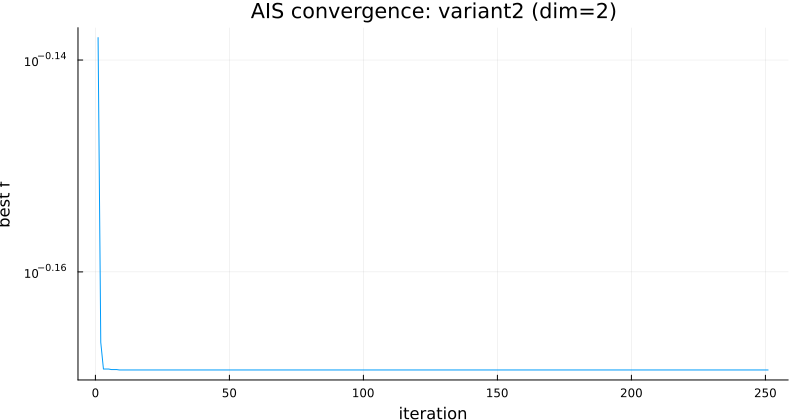

In [4]:
name = "variant2"
f, bounds = TEST_FUNCS[name]

dim = 2
res = immune_optimize(f; dim, bounds, Np=80, s=12, d=12, K=250, clone_mode=:proportional, η=0.6, r=0.2, seed=1)

println("Function: ", name)
println("Best f: ", res.best_f)
println("Best x: ", res.best_x)

p = plot(res.best_trace; xlabel="iteration", ylabel="best f", title="AIS convergence: $name (dim=$dim)", yscale=:log10, legend=false)
showplot(p)

best f (2D): 0.6772306998355893


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab22\lab22_ais_variant2.gif
┌ Info: GIF saved
│   path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\lab22_ais_variant2.gif"
└   frames_dir = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\.plot_display_cache\\gif_frames\\ais_gif_1771064572374000"


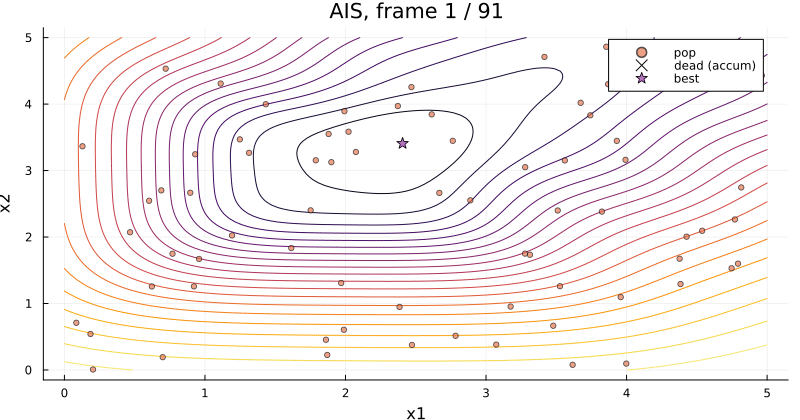

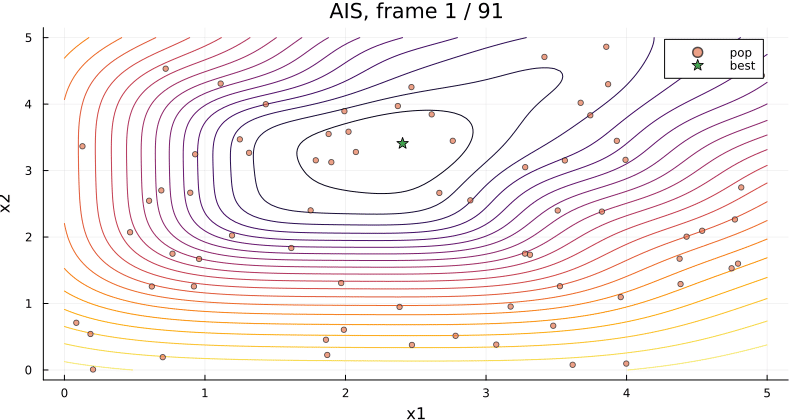

In [5]:
gif_name = "variant2"
fg, bg = TEST_FUNCS[gif_name]

out_gif = joinpath(LAB22_ROOT, "lab22_ais_$(gif_name).gif")
path, frames_dir, res2 = ais_make_gif_2d(
    fg;
    bounds = bg,
    out_path = out_gif,
    Np = 70,
    s = 12,
    d = 10,
    K = 180,
    clone_mode = :proportional,
    η = 0.6,
    r = 0.2,
    seed = 2,
    record_every = 2,
    fps = 12,
)

@info "GIF saved" path frames_dir
println("best f (2D): ", res2.best_f)
showgif(path)

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab22\lab22_ais_banana.gif
┌ Info: GIF saved
│   gif_name = "banana"
│   path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\lab22_ais_banana.gif"
└   frames_dir = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\.plot_display_cache\\gif_frames\\ais_gif_1771223876697900"


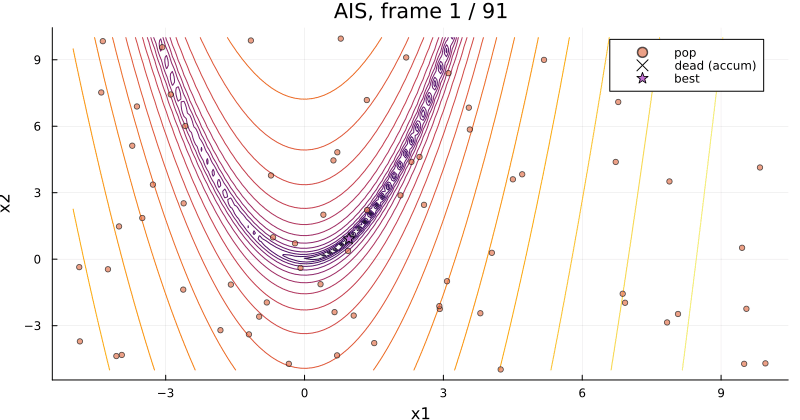

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab22\lab22_ais_rastrigin.gif
┌ Info: GIF saved
│   gif_name = "rastrigin"
│   path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\lab22_ais_rastrigin.gif"
└   frames_dir = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab22\\.plot_display_cache\\gif_frames\\ais_gif_1771233380586800"


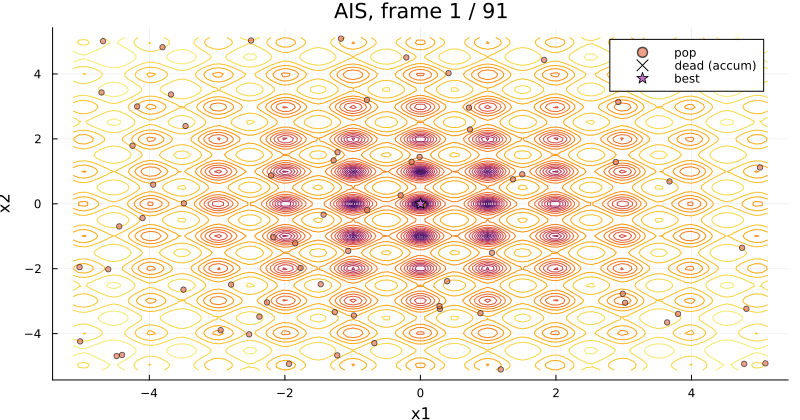

In [ ]:
for gif_name in ["banana", "rastrigin"]
    fg, bg = TEST_FUNCS[gif_name]
    out_gif = joinpath(LAB22_ROOT, "lab22_ais_$(gif_name).gif")

    path, frames_dir, res2 = ais_make_gif_2d(
        fg;
        bounds = bg,
        out_path = out_gif,
        Np = 70,
        s = 12,
        d = 10,
        K = 180,
        clone_mode = :proportional,
        η = 0.6,
        r = 0.2,
        seed = 3,
        record_every = 2,
        fps = 12,
    )

    @info "GIF saved" gif_name path frames_dir
    showgif(path)
end
